In [7]:
!mkdir -p ~/.kaggle
!echo KGAT_b4523a2ab3b1ad6bc1a7801b814c0698 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
!pip install -q kaggle

In [8]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [9]:
kaggle competitions download -c histopathologic-cancer-detection
!unzip -q histopathologic-cancer-detection.zip -d hist_data
!ls hist_data!

100% 6.31G/6.31G [01:12<00:00, 93.6MB/s]

sample_submission.csv  test  train  train_labels.csv


In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("hist_data/train_labels.csv")
print(df.shape)
print(df['label'].value_counts())

n_per_class = 4000
df_small = pd.concat([
    df[df.label == 0].sample(n_per_class, random_state=42),
    df[df.label == 1].sample(n_per_class, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

df_small['filepath'] = df_small['id'].apply(lambda x: f"hist_data/train/{x}.tif")
print(df_small.shape)

(220025, 2)
label
0    130908
1     89117
Name: count, dtype: int64
(8000, 3)


In [17]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from PIL import Image

train_df, val_df = train_test_split(df_small, test_size=0.2, stratify=df_small['label'], random_state=42)

IMG_SIZE = 96

def load_tif(path):
    path = path.numpy().decode("utf-8")
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img, dtype=np.float32)   # <-- no /255.0 here
    return img

def load_img(path, label):
    img = tf.py_function(func=load_tif, inp=[path], Tout=tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label

def make_dataset(df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df['filepath'].values, df['label'].values))
    ds = ds.map(load_img, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)

In [18]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("best_model.keras", save_best_only=True, monitor='val_accuracy', mode='max')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[checkpoint]
)

Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 108ms/step - accuracy: 0.8052 - loss: 0.4237 - val_accuracy: 0.8375 - val_loss: 0.3768
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.8342 - loss: 0.3679 - val_accuracy: 0.8425 - val_loss: 0.3684
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.8428 - loss: 0.3519 - val_accuracy: 0.8462 - val_loss: 0.3565
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.8516 - loss: 0.3306 - val_accuracy: 0.8444 - val_loss: 0.3520
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step - accuracy: 0.8672 - loss: 0.3047 - val_accuracy: 0.8381 - val_loss: 0.3918
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.8670 - loss: 0.3034 - val_accuracy: 0.8506 - val_loss: 0.3434
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.8764 - loss: 0.2844 - val_accuracy: 0.8556 - val_loss: 0.3437
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 66ms/step - accuracy: 0.8805 - loss: 0.2774 - val_acc

In [20]:
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

model = load_model("best_model.keras")

y_true = val_df['label'].values
y_pred_prob = model.predict(val_ds).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_true, y_pred, target_names=['No Cancer', 'Cancer']))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_pred_prob))

50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step
              precision    recall  f1-score   support

   No Cancer       0.85      0.87      0.86       800
      Cancer       0.86      0.84      0.85       800

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600

Confusion Matrix:
 [[694 106]
 [125 675]]
ROC-AUC: 0.9296828125000001


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


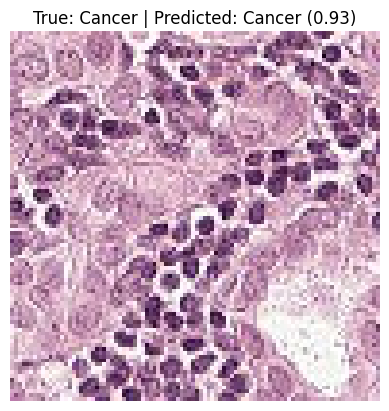

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

idx = 0
sample_path = val_df.iloc[idx]['filepath']
true_label = val_df.iloc[idx]['label']

img = Image.open(sample_path).convert("RGB").resize((96, 96))
img_arr = np.array(img, dtype=np.float32)

pred = model.predict(np.expand_dims(img_arr, axis=0))[0][0]

plt.imshow(img)
plt.title(f"True: {'Cancer' if true_label else 'No Cancer'} | Predicted: {'Cancer' if pred>0.5 else 'No Cancer'} ({pred:.2f})")
plt.axis('off')
plt.show()

In [22]:
from google.colab import files
files.download("best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Using layer: top_activation


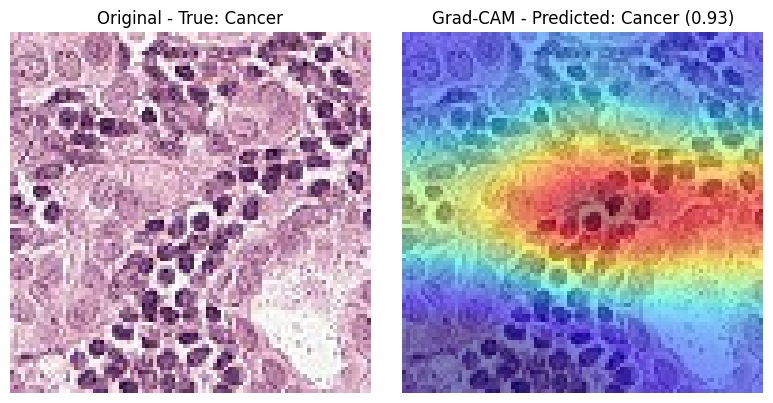

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

base_model = model.layers[0]

last_conv_layer_name = None
for layer in reversed(base_model.layers):
    try:
        shape = layer.output.shape
    except AttributeError:
        continue
    if shape is not None and len(shape) == 4:
        last_conv_layer_name = layer.name
        break
print("Using layer:", last_conv_layer_name)

conv_extractor = tf.keras.Model(base_model.input, base_model.get_layer(last_conv_layer_name).output)
classifier_layers = model.layers[1:]

def make_gradcam(img_array):
    img_array = np.expand_dims(img_array, axis=0)
    with tf.GradientTape() as tape:
        conv_out = conv_extractor(img_array)
        tape.watch(conv_out)
        x = conv_out
        for layer in classifier_layers:
            x = layer(x)
        preds = x
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()[0][0]

idx = 0
sample_path = val_df.iloc[idx]['filepath']
true_label = val_df.iloc[idx]['label']
img = Image.open(sample_path).convert("RGB").resize((96, 96))
img_arr = np.array(img, dtype=np.float32)

heatmap, pred = make_gradcam(img_arr)
heatmap_resized = np.array(Image.fromarray(np.uint8(255*heatmap)).resize((96, 96)))

true_text = "Cancer" if true_label == 1 else "No Cancer"
pred_text = "Cancer" if pred > 0.5 else "No Cancer"

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title("Original - True: " + true_text)
axes[0].axis('off')

axes[1].imshow(img)
axes[1].imshow(heatmap_resized, cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM - Predicted: " + pred_text + " (" + str(round(float(pred), 2)) + ")")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [30]:
from google.colab import files
files.download("best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
plt.savefig("gradcam_result.png", dpi=150, bbox_inches='tight')
from google.colab import files
files.download("gradcam_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


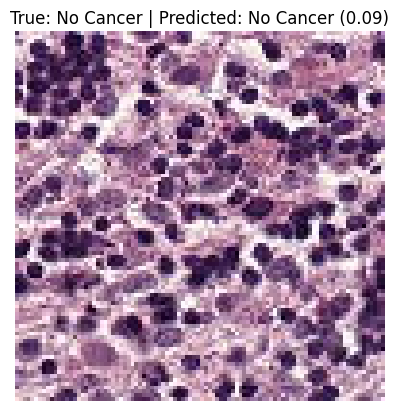

('No Cancer', np.float32(0.09275915))

In [32]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(path, true_label=None):
    img = Image.open(path).convert("RGB").resize((96, 96))
    img_arr = np.array(img, dtype=np.float32)
    img_arr = np.expand_dims(img_arr, axis=0)

    pred = model.predict(img_arr)[0][0]
    result = "Cancer" if pred > 0.5 else "No Cancer"

    plt.imshow(img)
    title = "Predicted: " + result + " (" + str(round(float(pred), 2)) + ")"
    if true_label is not None:
        true_text = "Cancer" if true_label == 1 else "No Cancer"
        title = "True: " + true_text + " | " + title
    plt.title(title)
    plt.axis('off')
    plt.show()

    return result, pred

# Test on a random patient from the validation set
row = val_df.sample(1).iloc[0]
predict_image(row['filepath'], row['label'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


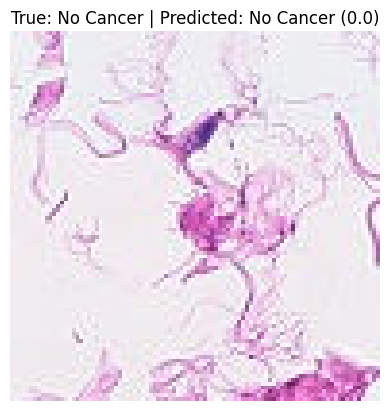

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


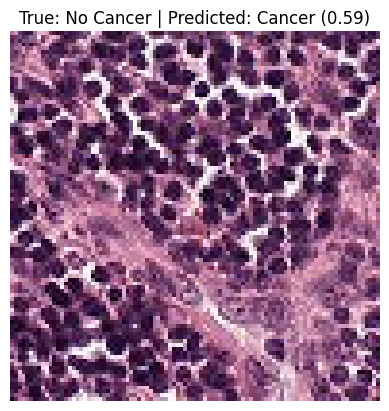

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


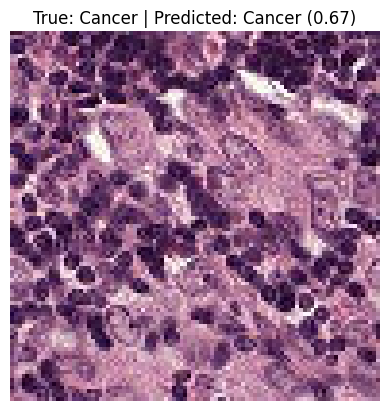

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


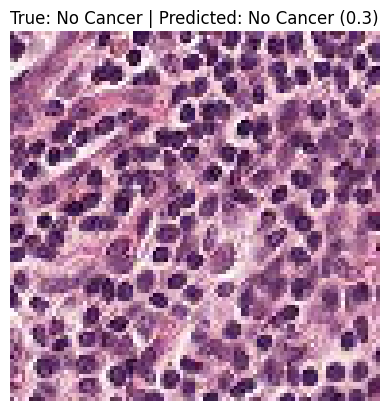

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


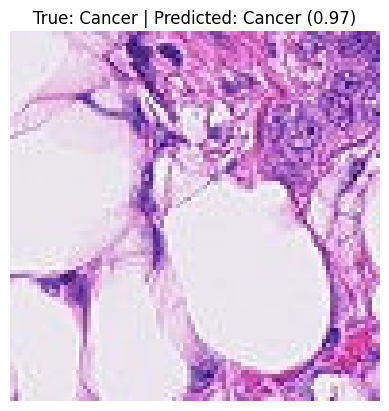

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

def predict_and_save(path, true_label, save_name):
    img = Image.open(path).convert("RGB").resize((96, 96))
    img_arr = np.array(img, dtype=np.float32)
    img_input = np.expand_dims(img_arr, axis=0)

    pred = model.predict(img_input)[0][0]
    result = "Cancer" if pred > 0.5 else "No Cancer"
    true_text = "Cancer" if true_label == 1 else "No Cancer"

    plt.figure()
    plt.imshow(img)
    plt.title("True: " + true_text + " | Predicted: " + result + " (" + str(round(float(pred), 2)) + ")")
    plt.axis('off')
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

sample_rows = val_df.sample(5)
saved_files = []
for i, (_, row) in enumerate(sample_rows.iterrows()):
    filename = "sample_" + str(i+1) + ".png"
    predict_and_save(row['filepath'], row['label'], filename)
    saved_files.append(filename)

for f in saved_files:
    files.download(f)

Saving ChatGPT Image Jul 18, 2026, 02_21_26 PM.png to ChatGPT Image Jul 18, 2026, 02_21_26 PM.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


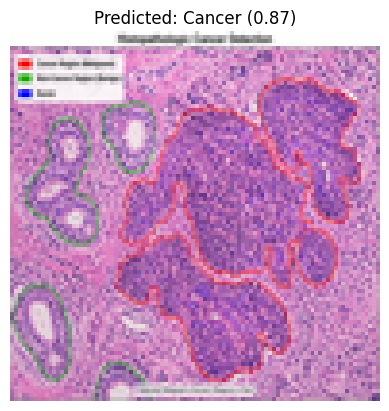

In [34]:
from google.colab import files
uploaded = files.upload()   # choose any tissue image file (.tif, .png, or .jpg) from your computer

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

uploaded_filename = list(uploaded.keys())[0]
img = Image.open(uploaded_filename).convert("RGB").resize((96, 96))
img_arr = np.array(img, dtype=np.float32)
img_input = np.expand_dims(img_arr, axis=0)

pred = model.predict(img_input)[0][0]
result = "Cancer" if pred > 0.5 else "No Cancer"

plt.imshow(img)
plt.title("Predicted: " + result + " (" + str(round(float(pred), 2)) + ")")
plt.axis('off')
plt.show()